# Decision Trees and Naive Bayes: Classification and Regression

**Context:** Guided model-building activities, consolidated and extended for portfolio presentation  
**Tools:** Python, pandas, scikit-learn, Matplotlib, seaborn  
**Methods:** decision-tree classification and regression, Gaussian and Bernoulli Naive Bayes,
cross-validation, hyperparameter search, leakage-safe preprocessing, baseline comparison

## TL;DR

- A cross-validated Diabetes decision tree reaches **0.802 ROC-AUC** on an untouched
  192-row holdout, but recall is only **47.8%**. Accuracy alone would hide this limitation.
- A two-feature breast-tumour tree reaches **87.7% accuracy** and **0.947 ROC-AUC**, while
  missing 11 of 42 malignant holdout cases. It is an educational visual model, not a
  diagnostic system.
- On Auto MPG, the tuned regression tree records **3.91 MPG RMSE**; a linear-regression
  baseline performs better at **3.54 MPG RMSE**. The tree is therefore not the preferred
  model on this split.
- Gaussian Naive Bayes reaches **92.1% holdout accuracy** on Iris. A feature-appropriate
  Bernoulli Naive Bayes pipeline reaches **0.891 ROC-AUC**, **81.4% recall**, and **55.6%
  precision** on Adult income classification.

## Context & Methods

This notebook compares two interpretable model families across classification and regression:

1. decision-tree classification on Diabetes and breast-tumour measurements;
2. decision-tree regression on vehicle fuel economy;
3. Gaussian Naive Bayes on continuous Iris measurements; and
4. Bernoulli Naive Bayes on binned and one-hot-encoded Adult features.

### Key assumptions

- Hyperparameters are selected only through cross-validation on training data.
- Final metrics are calculated once on untouched holdout partitions.
- Physiologically implausible zeros in selected Diabetes measurements represent missing
  measurements and are imputed inside the model pipeline.
- Adult `?` sentinels represent missing categories; exact duplicate rows are removed before
  splitting.
- Breast-tumour and Diabetes examples are educational only and have no clinical validity.
- Adult includes sensitive demographic attributes and is not a fairness assessment or a
  system suitable for employment, lending, or eligibility decisions.

## Setup

Place `diabetes.csv`, `breast_cancer.csv`, `auto_mpg.csv`, and `adult.csv` in this project's
`data/` folder. Raw teaching datasets are excluded because redistribution permissions have
not been established. The Iris dataset loads directly from scikit-learn.

References:

- [scikit-learn: decision trees](https://scikit-learn.org/stable/modules/tree.html)
- [scikit-learn: Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)
- [scikit-learn: pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- [scikit-learn: model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html)

In [1]:
from pathlib import Path
import hashlib
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_iris
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    root_mean_squared_error,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def locate_data_file(filename, environment_variable):
    environment_path = os.getenv(environment_variable)
    candidates = [
        Path(environment_path) if environment_path else None,
        Path("data") / filename,
        Path("decision-trees-and-naive-bayes/data") / filename,
        Path("../decision-trees-and-naive-bayes/data") / filename,
    ]
    for candidate in candidates:
        if candidate is not None and candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename!r}. Add it to this project's data/ folder."
    )


data_paths = {
    "Diabetes": locate_data_file("diabetes.csv", "DIABETES_DATA_PATH"),
    "Breast cancer": locate_data_file(
        "breast_cancer.csv", "BREAST_CANCER_DATA_PATH"
    ),
    "Auto MPG": locate_data_file("auto_mpg.csv", "AUTO_MPG_DATA_PATH"),
    "Adult": locate_data_file("adult.csv", "ADULT_DATA_PATH"),
}

## Data

In [3]:
adult_columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

diabetes = pd.read_csv(data_paths["Diabetes"])
breast_cancer = pd.read_csv(data_paths["Breast cancer"])
auto_mpg = pd.read_csv(data_paths["Auto MPG"])
adult_raw = pd.read_csv(
    data_paths["Adult"],
    header=None,
    names=adult_columns,
    skipinitialspace=True,
)

data_profile = pd.DataFrame(
    {
        "rows": [len(diabetes), len(breast_cancer), len(auto_mpg), len(adult_raw)],
        "columns": [
            diabetes.shape[1], breast_cancer.shape[1], auto_mpg.shape[1],
            adult_raw.shape[1]
        ],
        "encoded_missing_cells": [
            int(diabetes.isna().sum().sum()),
            int(breast_cancer.isna().sum().sum()),
            int(auto_mpg.isna().sum().sum()),
            int(adult_raw.isna().sum().sum()),
        ],
        "exact_duplicates": [
            int(diabetes.duplicated().sum()),
            int(breast_cancer.duplicated().sum()),
            int(auto_mpg.duplicated().sum()),
            int(adult_raw.duplicated().sum()),
        ],
        "sha256": [
            hashlib.sha256(data_paths[name].read_bytes()).hexdigest()
            for name in ["Diabetes", "Breast cancer", "Auto MPG", "Adult"]
        ],
    },
    index=["Diabetes", "Breast cancer", "Auto MPG", "Adult"],
)
data_profile

,rows,columns,encoded_missing_cells,exact_duplicates,sha256
Diabetes,768,9,0,0,698c203a14aa31941d2251175330c9199f3ccdb31597ab...
Breast cancer,569,33,569,0,1425d9affa78ba8e53afc81d0ef8a19069ee10c4b21fe8...
Auto MPG,398,9,0,0,09a282cf12c7ab4ffb517b496b0dd1a8bac6e95977178c...
Adult,32561,15,0,24,5b00264637dbfec36bdeaab5676b0b309ff9eb788d6355...


In [4]:
assert set(diabetes.columns) == {
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
}
assert {"diagnosis", "radius_mean", "concave points_mean"}.issubset(
    breast_cancer.columns
)
assert set(auto_mpg.columns) == {
    "mpg", "cylinders", "displacement", "horsepower", "weight",
    "acceleration", "model year", "origin", "car name"
}
assert list(adult_raw.columns) == adult_columns
assert set(diabetes["Outcome"].unique()) == {0, 1}
assert set(breast_cancer["diagnosis"].unique()) == {"B", "M"}
print("All input schemas and target labels validated.")

All input schemas and target labels validated.


## Results

### 1. Diabetes decision-tree classification

In [5]:
diabetes_X = diabetes.drop(columns="Outcome").copy()
diabetes_y = diabetes["Outcome"].copy()
zero_as_missing = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]
diabetes_X[zero_as_missing] = diabetes_X[zero_as_missing].replace(0, np.nan)

diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = (
    train_test_split(
        diabetes_X,
        diabetes_y,
        test_size=0.25,
        stratify=diabetes_y,
        random_state=RANDOM_STATE,
    )
)

diabetes_tree_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)
diabetes_search = GridSearchCV(
    diabetes_tree_pipeline,
    param_grid={
        "tree__criterion": ["gini", "entropy"],
        "tree__max_depth": [2, 3, 4, 5, 6, None],
        "tree__min_samples_leaf": [5, 10, 20, 30],
    },
    scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
    refit=True,
)
diabetes_search.fit(diabetes_X_train, diabetes_y_train)

pd.Series(
    {
        "best_cv_roc_auc": diabetes_search.best_score_,
        **diabetes_search.best_params_,
    },
    name="Selected tree",
).to_frame()

,Selected tree
best_cv_roc_auc,0.8064
tree__criterion,entropy
tree__max_depth,5
tree__min_samples_leaf,20


In [6]:
def binary_metrics(y_true, predictions, probabilities):
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
    }


diabetes_predictions = diabetes_search.predict(diabetes_X_test)
diabetes_probabilities = diabetes_search.predict_proba(diabetes_X_test)[:, 1]
diabetes_metrics = pd.Series(
    binary_metrics(
        diabetes_y_test, diabetes_predictions, diabetes_probabilities
    ),
    name="Diabetes tree holdout",
)
diabetes_metrics.round(4).to_frame()

,Diabetes tree holdout
accuracy,0.7292
balanced_accuracy,0.6708
precision,0.6531
recall,0.4776
f1,0.5517
roc_auc,0.8016
average_precision,0.6007


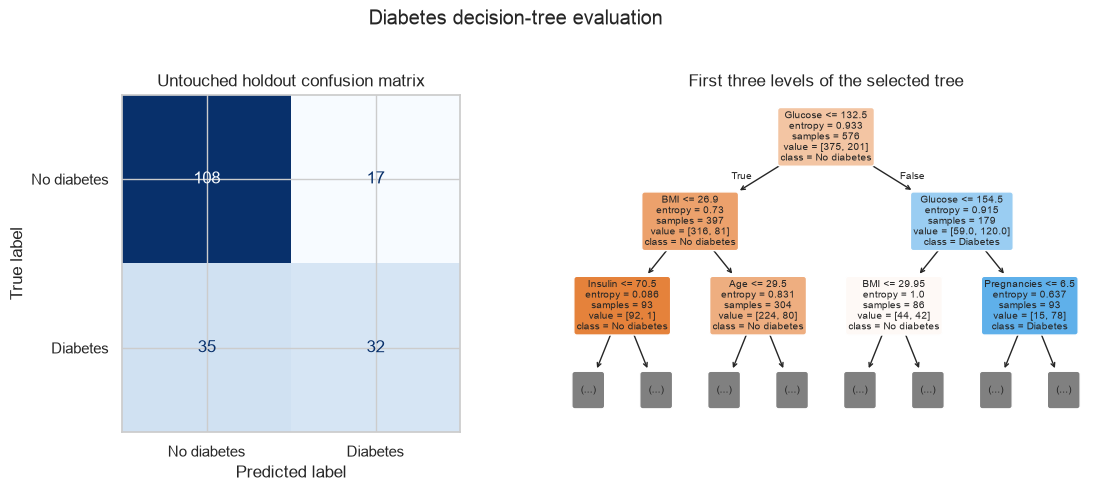

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ConfusionMatrixDisplay.from_predictions(
    diabetes_y_test,
    diabetes_predictions,
    display_labels=["No diabetes", "Diabetes"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Untouched holdout confusion matrix")

selected_diabetes_tree = diabetes_search.best_estimator_.named_steps["tree"]
plot_tree(
    selected_diabetes_tree,
    feature_names=diabetes_X.columns,
    class_names=["No diabetes", "Diabetes"],
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=7,
    ax=axes[1],
)
axes[1].set_title("First three levels of the selected tree")
figure.suptitle("Diabetes decision-tree evaluation", y=1.02)
plt.tight_layout()
plt.show()

The tree is tuned by training-fold ROC-AUC, not by the test set. Its holdout ROC-AUC is
0.802, but it identifies only 32 of 67 positive cases. This low recall is a material
limitation that overall accuracy does not communicate.

### 2. Two-feature breast-tumour decision tree

In [8]:
tumour_features = ["radius_mean", "concave points_mean"]
tumour_X = breast_cancer[tumour_features].copy()
tumour_y = breast_cancer["diagnosis"].map({"B": 0, "M": 1})

tumour_X_train, tumour_X_test, tumour_y_train, tumour_y_test = train_test_split(
    tumour_X,
    tumour_y,
    test_size=0.20,
    stratify=tumour_y,
    random_state=RANDOM_STATE,
)
tumour_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={
        "criterion": ["gini", "entropy"],
        "max_depth": [2, 3, 4, 5, 6, 8, None],
        "min_samples_leaf": [2, 5, 10, 20],
    },
    scoring="roc_auc",
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
    refit=True,
)
tumour_search.fit(tumour_X_train, tumour_y_train)

tumour_predictions = tumour_search.predict(tumour_X_test)
tumour_probabilities = tumour_search.predict_proba(tumour_X_test)[:, 1]
tumour_metrics = pd.Series(
    binary_metrics(tumour_y_test, tumour_predictions, tumour_probabilities),
    name="Two-feature tree holdout",
)
print("Best parameters:", tumour_search.best_params_)
print(f"Best training CV ROC-AUC: {tumour_search.best_score_:.4f}")
tumour_metrics.round(4).to_frame()

Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5}
Best training CV ROC-AUC: 0.9720


,Two-feature tree holdout
accuracy,0.8772
balanced_accuracy,0.8482
precision,0.9118
recall,0.7381
f1,0.8158
roc_auc,0.9466
average_precision,0.8841


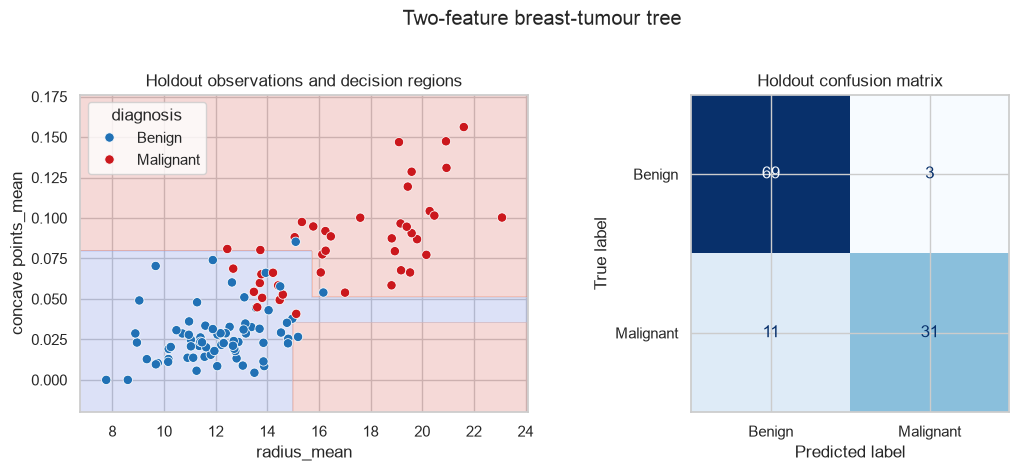

In [9]:
x_min, x_max = tumour_X_test.iloc[:, 0].min() - 1, tumour_X_test.iloc[:, 0].max() + 1
y_min, y_max = (
    tumour_X_test.iloc[:, 1].min() - 0.02,
    tumour_X_test.iloc[:, 1].max() + 0.02,
)
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350), np.linspace(y_min, y_max, 350)
)
grid = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()], columns=tumour_features
)
regions = tumour_search.predict(grid).reshape(xx.shape)

figure, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].contourf(xx, yy, regions, alpha=0.20, cmap="coolwarm")
sns.scatterplot(
    data=tumour_X_test.assign(diagnosis=tumour_y_test.map({0: "Benign", 1: "Malignant"})),
    x="radius_mean",
    y="concave points_mean",
    hue="diagnosis",
    palette={"Benign": "#2171b5", "Malignant": "#cb181d"},
    s=45,
    ax=axes[0],
)
axes[0].set_title("Holdout observations and decision regions")

ConfusionMatrixDisplay.from_predictions(
    tumour_y_test,
    tumour_predictions,
    display_labels=["Benign", "Malignant"],
    cmap="Blues",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Holdout confusion matrix")
figure.suptitle("Two-feature breast-tumour tree", y=1.02)
plt.tight_layout()
plt.show()

Limiting the model to two measurements makes the decision regions visible but sacrifices
information. The model misses 11 of 42 malignant holdout cases. This trade-off is acceptable
for a teaching visualisation, not for medical diagnosis.

### 3. Auto MPG decision-tree regression

In [10]:
auto_mpg = auto_mpg.copy()
auto_mpg["horsepower"] = pd.to_numeric(auto_mpg["horsepower"], errors="coerce")
mpg_X = auto_mpg.drop(columns=["mpg", "car name"])
mpg_y = auto_mpg["mpg"]
mpg_numeric = [
    "cylinders", "displacement", "horsepower", "weight", "acceleration", "model year"
]
mpg_categorical = ["origin"]

mpg_preprocessor = ColumnTransformer(
    [
        ("numeric", SimpleImputer(strategy="median"), mpg_numeric),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), mpg_categorical),
    ]
)
mpg_X_train, mpg_X_test, mpg_y_train, mpg_y_test = train_test_split(
    mpg_X, mpg_y, test_size=0.20, random_state=3
)

mpg_tree_pipeline = Pipeline(
    [
        ("preprocessor", mpg_preprocessor),
        ("tree", DecisionTreeRegressor(random_state=3)),
    ]
)
mpg_search = GridSearchCV(
    mpg_tree_pipeline,
    param_grid={
        "tree__max_depth": [2, 3, 4, 5, 6, 8, None],
        "tree__min_samples_leaf": [2, 5, 10, 20, 30],
    },
    scoring="neg_root_mean_squared_error",
    cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
    refit=True,
)
mpg_search.fit(mpg_X_train, mpg_y_train)

mpg_linear_baseline = Pipeline(
    [
        ("preprocessor", mpg_preprocessor),
        ("model", LinearRegression()),
    ]
).fit(mpg_X_train, mpg_y_train)

In [11]:
mpg_tree_predictions = mpg_search.predict(mpg_X_test)
mpg_linear_predictions = mpg_linear_baseline.predict(mpg_X_test)

def regression_metrics(y_true, predictions):
    return {
        "MAE": mean_absolute_error(y_true, predictions),
        "RMSE": root_mean_squared_error(y_true, predictions),
        "R2": r2_score(y_true, predictions),
    }


mpg_metrics = pd.DataFrame(
    {
        "Decision tree": regression_metrics(mpg_y_test, mpg_tree_predictions),
        "Linear baseline": regression_metrics(mpg_y_test, mpg_linear_predictions),
    }
)
print("Best tree parameters:", mpg_search.best_params_)
print(f"Best tree training CV RMSE: {-mpg_search.best_score_:.3f} MPG")
mpg_metrics.round(4)

Best tree parameters: {'tree__max_depth': 8, 'tree__min_samples_leaf': 5}
Best tree training CV RMSE: 2.979 MPG


,Decision tree,Linear baseline
MAE,2.8591,2.7394
RMSE,3.9131,3.5368
R2,0.7523,0.7976


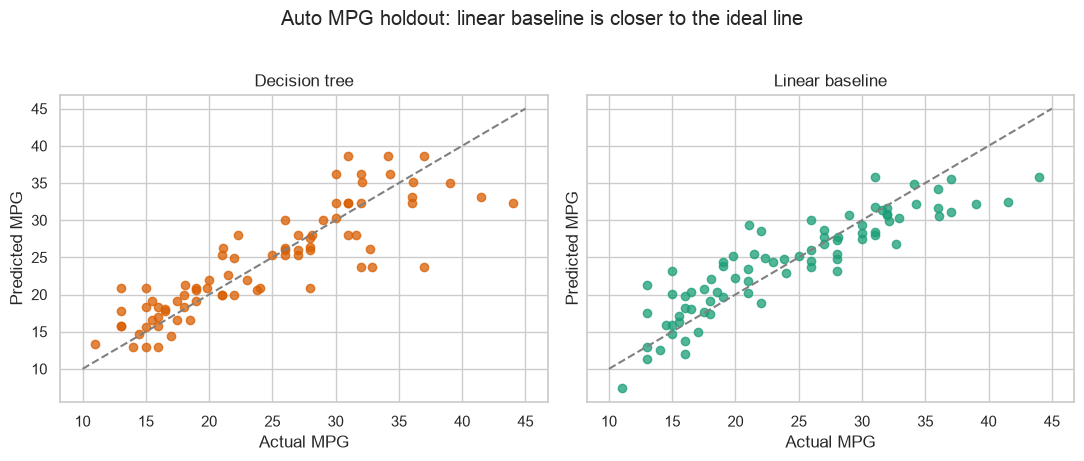

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
bounds = [mpg_y_test.min() - 1, mpg_y_test.max() + 1]
for axis, predictions, title, color in [
    (axes[0], mpg_tree_predictions, "Decision tree", "#d95f02"),
    (axes[1], mpg_linear_predictions, "Linear baseline", "#1b9e77"),
]:
    axis.scatter(mpg_y_test, predictions, alpha=0.75, color=color)
    axis.plot(bounds, bounds, linestyle="--", color="grey")
    axis.set_title(title)
    axis.set_xlabel("Actual MPG")
    axis.set_ylabel("Predicted MPG")
figure.suptitle("Auto MPG holdout: linear baseline is closer to the ideal line", y=1.02)
plt.tight_layout()
plt.show()

Cross-validation tunes the regression tree without using the holdout. On the final test set,
however, the linear baseline has lower error and higher R². The exercise therefore supports
applying a tree, but not selecting it over the baseline.

### 4. Gaussian Naive Bayes on Iris

In [13]:
iris_bundle = load_iris(as_frame=True)
iris_X = iris_bundle.data.copy()
iris_y = iris_bundle.target.copy()
iris_X_train, iris_X_test, iris_y_train, iris_y_test = train_test_split(
    iris_X,
    iris_y,
    test_size=0.25,
    stratify=iris_y,
    random_state=RANDOM_STATE,
)
iris_cv = cross_validate(
    GaussianNB(),
    iris_X_train,
    iris_y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring={"accuracy": "accuracy", "macro_f1": "f1_macro"},
    n_jobs=1,
)
iris_nb = GaussianNB().fit(iris_X_train, iris_y_train)
iris_predictions = iris_nb.predict(iris_X_test)

pd.Series(
    {
        "cv_accuracy_mean": iris_cv["test_accuracy"].mean(),
        "cv_macro_f1_mean": iris_cv["test_macro_f1"].mean(),
        "holdout_accuracy": accuracy_score(iris_y_test, iris_predictions),
        "holdout_macro_f1": f1_score(
            iris_y_test, iris_predictions, average="macro"
        ),
    },
    name="Gaussian NB",
).round(4).to_frame()

,Gaussian NB
cv_accuracy_mean,0.9735
cv_macro_f1_mean,0.9731
holdout_accuracy,0.9211
holdout_macro_f1,0.9230


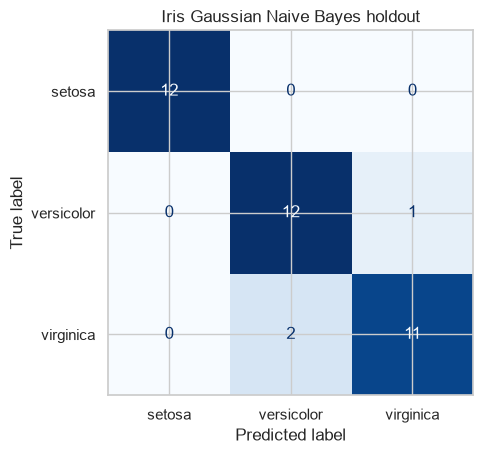

In [14]:
figure, axis = plt.subplots(figsize=(5.8, 4.7))
ConfusionMatrixDisplay.from_predictions(
    iris_y_test,
    iris_predictions,
    display_labels=iris_bundle.target_names,
    cmap="Blues",
    colorbar=False,
    ax=axis,
)
axis.set_title("Iris Gaussian Naive Bayes holdout")
plt.tight_layout()
plt.show()

### 5. Bernoulli Naive Bayes on Adult income

In [15]:
adult = adult_raw.drop_duplicates().replace("?", np.nan).copy()
adult_y = adult.pop("income").map({"<=50K": 0, ">50K": 1})
adult_X = adult
adult_numeric = adult_X.select_dtypes(exclude="object").columns.tolist()
adult_categorical = adult_X.select_dtypes(include="object").columns.tolist()

adult_preprocessor = ColumnTransformer(
    [
        (
            "numeric_bins",
            KBinsDiscretizer(
                n_bins=10,
                encode="onehot",
                strategy="uniform",
            ),
            adult_numeric,
        ),
        (
            "categories",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            adult_categorical,
        ),
    ]
)
adult_nb_pipeline = Pipeline(
    [
        ("preprocessor", adult_preprocessor),
        ("model", BernoulliNB(alpha=1.0)),
    ]
)
adult_X_train, adult_X_test, adult_y_train, adult_y_test = train_test_split(
    adult_X,
    adult_y,
    test_size=0.20,
    stratify=adult_y,
    random_state=RANDOM_STATE,
)
adult_cv = cross_validate(
    adult_nb_pipeline,
    adult_X_train,
    adult_y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision",
    },
    n_jobs=1,
)
adult_nb_pipeline.fit(adult_X_train, adult_y_train)
adult_predictions = adult_nb_pipeline.predict(adult_X_test)
adult_probabilities = adult_nb_pipeline.predict_proba(adult_X_test)[:, 1]

In [16]:
adult_metrics = pd.Series(
    binary_metrics(adult_y_test, adult_predictions, adult_probabilities),
    name="Adult Bernoulli NB holdout",
)
adult_cv_summary = pd.Series(
    {
        metric: adult_cv[f"test_{metric}"].mean()
        for metric in [
            "accuracy", "balanced_accuracy", "f1", "roc_auc", "average_precision"
        ]
    },
    name="5-fold training CV",
)
pd.concat([adult_cv_summary, adult_metrics], axis=1).round(4)

,5-fold training CV,Adult Bernoulli NB holdout
accuracy,0.7971,0.7987
balanced_accuracy,0.7985,0.8041
f1,0.6555,0.6610
roc_auc,0.8896,0.8913
average_precision,0.7292,0.7362
precision,NaN,0.5562
recall,NaN,0.8144


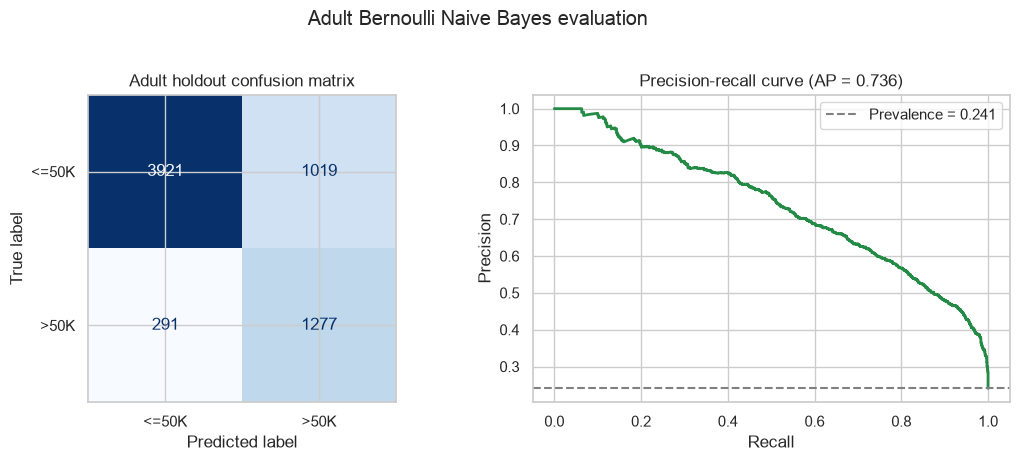

In [17]:
adult_precision_curve, adult_recall_curve, _ = precision_recall_curve(
    adult_y_test, adult_probabilities
)
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(
    adult_y_test,
    adult_predictions,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Adult holdout confusion matrix")

axes[1].plot(adult_recall_curve, adult_precision_curve, color="#238b45", linewidth=2)
axes[1].axhline(
    adult_y_test.mean(),
    linestyle="--",
    color="grey",
    label=f"Prevalence = {adult_y_test.mean():.3f}",
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(
    f"Precision-recall curve (AP = {adult_metrics['average_precision']:.3f})"
)
axes[1].legend(loc="upper right")
figure.suptitle("Adult Bernoulli Naive Bayes evaluation", y=1.02)
plt.tight_layout()
plt.show()

Bernoulli Naive Bayes is used instead of applying a Gaussian assumption to one-hot encoded
categories. Numeric variables are converted to one-hot interval indicators and categorical
variables are one-hot encoded inside the pipeline. The model identifies 81.4% of higher-income
cases but precision is 55.6%, illustrating the false-positive trade-off. Sensitive attributes
remain a major limitation; these results are not a fairness analysis.

## Checks

In [18]:
assert len(diabetes_X_train) + len(diabetes_X_test) == len(diabetes)
assert len(tumour_X_train) + len(tumour_X_test) == len(breast_cancer)
assert len(mpg_X_train) + len(mpg_X_test) == len(auto_mpg)
assert len(iris_X_train) + len(iris_X_test) == len(iris_X)
assert len(adult_X_train) + len(adult_X_test) == len(adult_X)
assert set(diabetes_X_train.index).isdisjoint(diabetes_X_test.index)
assert set(tumour_X_train.index).isdisjoint(tumour_X_test.index)
assert set(mpg_X_train.index).isdisjoint(mpg_X_test.index)
assert set(adult_X_train.index).isdisjoint(adult_X_test.index)
assert confusion_matrix(diabetes_y_test, diabetes_predictions).tolist() == [[108, 17], [35, 32]]
assert confusion_matrix(tumour_y_test, tumour_predictions).tolist() == [[69, 3], [11, 31]]
assert confusion_matrix(adult_y_test, adult_predictions).tolist() == [[3921, 1019], [291, 1277]]
assert root_mean_squared_error(mpg_y_test, mpg_linear_predictions) < root_mean_squared_error(
    mpg_y_test, mpg_tree_predictions
)
assert np.isfinite(adult_metrics).all()
print("All schema, split, selection, metric, and baseline checks passed.")

All schema, split, selection, metric, and baseline checks passed.


## Takeaways

- Tune tree complexity using training-fold validation, not the final test set.
- Accuracy is insufficient when false negatives matter; report recall, balanced accuracy,
  ROC-AUC, average precision, and the confusion matrix.
- Always compare a specialised model with a credible baseline. Auto MPG shows that a tuned
  tree can still lose to linear regression.
- Match the Naive Bayes variant to the feature representation: Gaussian for continuous
  measurements, Bernoulli for binary indicator features.
- Simple, interpretable models remain subject to data quality, fairness, calibration, and
  external-validity limitations.